In [51]:
from Bio import Entrez, Seq, SeqIO
from Bio.Alphabet import IUPAC

import gzip
import matplotlib.pyplot as plt

from collections import defaultdict

In [52]:
# 1.a
Entrez.email = "Ryan_Balachandran@student.uml.edu"
handle = Entrez.einfo()
record = Entrez.read(handle)
print(record)

{'DbList': ['pubmed', 'protein', 'nuccore', 'ipg', 'nucleotide', 'structure', 'genome', 'annotinfo', 'assembly', 'bioproject', 'biosample', 'blastdbinfo', 'books', 'cdd', 'clinvar', 'gap', 'gapplus', 'grasp', 'dbvar', 'gene', 'gds', 'geoprofiles', 'homologene', 'medgen', 'mesh', 'ncbisearch', 'nlmcatalog', 'omim', 'orgtrack', 'pmc', 'popset', 'proteinclusters', 'pcassay', 'protfam', 'biosystems', 'pccompound', 'pcsubstance', 'seqannot', 'snp', 'sra', 'taxonomy', 'biocollections', 'gtr']}


In [53]:
# 1.b
handle = Entrez.esearch(db="nucleotide", term='CRT[Gene Name] AND "Plasmodium falciparum”[Organism]', retmax = 50)
rec_list = Entrez.read(handle)
id_list = rec_list['IdList']
print(id_list)

['1955675406', '1955675404', '1955675402', '1955675400', '1955675398', '1955675396', '1955675394', '1955675392', '1955675390', '1955675388', '1955675386', '1955675384', '1955675382', '1955675380', '1955675378', '1955675376', '1955675374', '1955675372', '1746542926', '1746542924', '1746542922', '1746542920', '1746542918', '1746542916', '1746542914', '1746542912', '1746542910', '1746542908', '1746542906', '1746542904', '1746542902', '1746542900', '1746542898', '1746542896', '1746542894', '1746542892', '1746542890', '1746542888', '1746542886', '1746542884', '1746542882', '1746542880', '1746542878', '1746542876', '1746542874', '1746542872', '1746542870', '1746542868', '1746542866', '1746542864']


In [54]:
# 1.d
hdl = Entrez.efetch(db='nucleotide', id=id_list, rettype='gb')
recs = list(SeqIO.parse(hdl, 'gb'))
for gene in recs:
    if gene.name == 'MW267873':
        break
print(gene.name)
print(gene.description)

MW267873
Plasmodium falciparum isolate MM5 chloroquine resistance transporter (crt) gene, partial cds


In [55]:
# 1.e
for feature in gene.features:
    if feature.type == 'gene':
        print(feature.qualifiers['gene'])
    elif feature.type == 'exon':
        loc = feature.location
        print('Exon', loc.start, loc.end, loc.strand)
    else:
        print('not processed:\n%s' % feature)

for name, value in gene.annotations.items():
    print('%s=%s' % (name, value))

not processed:
type: source
location: [0:267](+)
qualifiers:
    Key: country, Value: ['Nigeria']
    Key: db_xref, Value: ['taxon:5833']
    Key: isolate, Value: ['MM5']
    Key: mol_type, Value: ['genomic DNA']
    Key: organism, Value: ['Plasmodium falciparum']

['crt']
not processed:
type: mRNA
location: [<1:>267](+)
qualifiers:
    Key: gene, Value: ['crt']
    Key: product, Value: ['chloroquine resistance transporter']

not processed:
type: CDS
location: [<1:>267](+)
qualifiers:
    Key: codon_start, Value: ['3']
    Key: gene, Value: ['crt']
    Key: note, Value: ['xenobiotic resistance transporter']
    Key: product, Value: ['chloroquine resistance transporter']
    Key: protein_id, Value: ['QQO86815.1']
    Key: translation, Value: ['GSRLGGGSCLGKCAHVFKLIFKEIKDNIFIYILSIIYLSVCVMNKIFAKRTLNKIGNYSFVTSETHNFICMIMFFIVYSLFGNKNGNS']

molecule_type=DNA
topology=linear
data_file_division=INV
date=18-JAN-2021
accessions=['MW267873']
sequence_version=1
keywords=['']
source=Plasmodium falcip

In [56]:
# 2.a
hdl = Entrez.efetch(db='nucleotide', id=['NM_002299'], rettype='fasta')
seq = SeqIO.read(hdl, 'fasta')
print(seq)

w_hdl = open('eg.fasta', 'w')
w_seq = seq[11:5795]
SeqIO.write([w_seq], w_hdl, 'fasta')
w_hdl.close()

ID: NM_002299.4
Name: NM_002299.4
Description: NM_002299.4 Homo sapiens lactase (LCT), mRNA
Number of features: 0
Seq('AACAGTTCCTAGAAAATGGAGCTGTCTTGGCATGTAGTCTTTATTGCCCTGCTA...GTC', SingleLetterAlphabet())


In [57]:
# 2.b
recs = SeqIO.parse('eg.fasta', 'fasta')
for rec in recs:
    seq = rec.seq
    print(rec.description)
    print(seq[:10])
    print(seq.alphabet)

NM_002299.4 Homo sapiens lactase (LCT), mRNA
GAAAATGGAG
SingleLetterAlphabet()


In [58]:
#2.c
seq = Seq.Seq(str(seq), IUPAC.unambiguous_dna)
print(seq, '\n')

rna = seq.transcribe()
print(rna, '\n')

protein = seq.translate()
print(protein)

GAAAATGGAGCTGTCTTGGCATGTAGTCTTTATTGCCCTGCTAAGTTTTTCATGCTGGGGGTCAGACTGGGAGTCTGATAGAAATTTCATTTCCACCGCTGGTCCTCTAACCAATGACTTGCTGCACAACCTGAGTGGTCTCCTGGGAGACCAGAGTTCTAACTTTGTAGCAGGGGACAAAGACATGTATGTTTGTCACCAGCCACTGCCCACTTTCCTGCCAGAATACTTCAGCAGTCTCCATGCCAGTCAGATCACCCATTATAAGGTATTTCTGTCATGGGCACAGCTCCTCCCAGCAGGAAGCACCCAGAATCCAGACGAGAAAACAGTGCAGTGCTACCGGCGACTCCTCAAGGCCCTCAAGACTGCACGGCTTCAGCCCATGGTCATCCTGCACCACCAGACCCTCCCTGCCAGCACCCTCCGGAGAACCGAAGCCTTTGCTGACCTCTTCGCCGACTATGCCACATTCGCCTTCCACTCCTTCGGGGACCTAGTTGGGATCTGGTTCACCTTCAGTGACTTGGAGGAAGTGATCAAGGAGCTTCCCCACCAGGAATCAAGAGCGTCACAACTCCAGACCCTCAGTGATGCCCACAGAAAAGCCTATGAGATTTACCACGAAAGCTATGCTTTTCAGGGCGGAAAACTCTCTGTTGTCCTGCGAGCTGAAGATATCCCGGAGCTCCTGCTAGAACCACCCATATCTGCGCTTGCCCAGGACACGGTCGATTTCCTCTCTCTTGATTTGTCTTATGAATGCCAAAATGAGGCAAGTCTGCGGCAGAAGCTGAGTAAATTGCAGACCATTGAGCCAAAAGTGAAAGTTTTCATCTTCAACCTAAAACTCCCAGACTGCCCCTCCACCATGAAGAACCCAGCCAGTCTGCTCTTCAGCCTTTTTGAAGCCATAAATAAAGACCAAGTGCTCACCATTGGGTTTGATATTAATGAGTTTCTGAGTTGTTCATCAAGTTCCAAGAAAAGCATGTCTTGT

In [59]:
# 3.b
recs = SeqIO.parse(gzip.open('SRR003265.filt.fastq.gz', 'rt', encoding='utf-8'), 'fastq')
rec = next(recs)
print(rec.id, rec.description)
print(rec.seq)
print(rec.letter_annotations)
print('\n')

SRR003265.31 SRR003265.31 3042NAAXX:3:1:1252:1819 length=51
GGGAAAAGAAAAACAAACAAACAAAAACAAAACACAGAAACAAAAAAACCA
{'phred_quality': [40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 30, 23, 40, 32, 35, 29, 40, 16, 40, 40, 32, 35, 31, 40, 40, 39, 22, 40, 24, 20, 28, 31, 12, 31, 10, 22, 28, 13, 26, 20, 23, 23]}




In [60]:
# 3.d
# comment this code section when running 3.e
cnt = defaultdict(int)
for rec in recs:
    for letter in rec.seq:
        cnt[letter] += 1
tot = sum(cnt.values())
for letter, cnt in cnt.items():
    print('%s: %.2f   %d' % (letter, 100.*cnt/tot, cnt))

G: 20.68   5359329
A: 28.60   7411928
T: 29.58   7666885
C: 21.00   5444044
N: 0.14   37289


In [61]:
# 3.b
recs = SeqIO.parse(gzip.open('SRR003265.filt.fastq.gz', 'rt', encoding='utf-8'), 'fastq')
rec = next(recs)
print(rec.id, rec.description)
print(rec.seq)
print(rec.letter_annotations)
print('\n')

SRR003265.31 SRR003265.31 3042NAAXX:3:1:1252:1819 length=51
GGGAAAAGAAAAACAAACAAACAAAAACAAAACACAGAAACAAAAAAACCA
{'phred_quality': [40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 30, 23, 40, 32, 35, 29, 40, 16, 40, 40, 32, 35, 31, 40, 40, 39, 22, 40, 24, 20, 28, 31, 12, 31, 10, 22, 28, 13, 26, 20, 23, 23]}




In [62]:
# 3.e
N_cnt = defaultdict(int)
for rec in recs:
    for i, letter in enumerate(rec.seq):
        pos = i+1
        if letter == 'N':
            N_cnt[pos] += 1
seq_len = max(N_cnt.keys())
positions = range(1, seq_len+1)

lists = sorted(N_cnt.items())
x, y = zip(*lists)

print(x, '\n')
print(y)

(26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51) 

(61, 48, 1792, 2472, 3108, 4192, 3978, 4662, 3988, 1668, 1006, 1661, 559, 454, 579, 768, 220, 383, 501, 1145, 414, 866, 464, 423, 651, 1226)


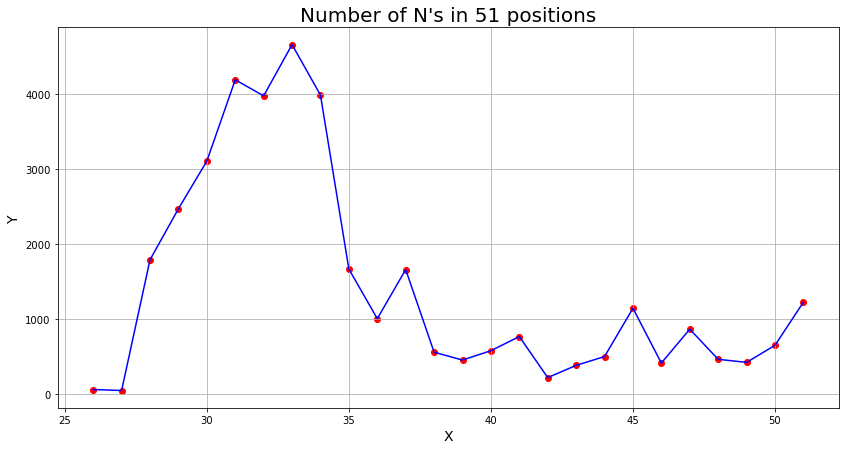

In [63]:
# Initialize a Figure 
fig = plt.figure(figsize=(14,7))
plt.title("Number of N's in 51 positions", size = 20)
plt.xlabel("X", size = 14)
plt.ylabel("Y", size = 14)
plt.grid(True)

plt.scatter(x, y, color = 'red')
plt.plot(x, y, color = 'blue')
plt.show()